# Optimized fuzzy-deduplication parameter search

This notebook searches a fixed, reproducible family of lexical fuzzy-deduplication rules against 466 LLM-annotated MCQA pairs. Every treatment uses the same normalized complete item: question followed by ordered, labeled choices. Answers and historical sampling metadata are excluded.

The primary selection objective is Matthews correlation coefficient (MCC). Hyperparameter selection and performance estimation are separated with repeated nested group cross-validation, where connected items remain in the same fold. The result is a provisional operating point for this enriched benchmark; no corpus records are removed.


In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata
import json
import math
import os
import platform
import shutil
import subprocess
from datetime import datetime, timezone
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.model_selection import StratifiedGroupKFold

from mmlu_pt.mcqa_minimal import normalize_question_for_dedup

RUN_SEARCH = False

EXPECTED_ANNOTATION_SHA256 = "a51cbf1099b969b0573abd104184bf91874df64f1dc09bbb5a418ac2110290a6"
EXPECTED_PAIRS = 466
EXPECTED_UNIQUE_ITEMS = 837
EXPECTED_GROUPS = 373
SEED = 42
MAX_HASHES = 270
NGRAM_WIDTHS = (8, 12, 16, 20, 24, 28, 30)
BANDINGS = (
    (8, 32), (10, 26), (12, 22), (13, 20), (14, 18), (15, 17), (16, 16),
    (18, 15), (20, 13), (22, 12), (24, 11), (26, 10), (30, 9), (32, 8),
)
MIN_MATCHING_BANDS = (1, 2)
JACCARD_THRESHOLDS = (None, *(value / 100 for value in range(60, 99)))
EXPECTED_CONFIGURATIONS = 7_840
EXPECTED_PREDICTIONS = 3_653_440
OUTER_SPLITS = 5
OUTER_REPEATS = 10
INNER_SPLITS = 4
CV_SEED = 20260911
BOOTSTRAP_REPLICATES = 10_000
VALID_LABELS = {"duplicate", "related_but_distinct", "distinct", "unsure"}
DECISIVE_LABELS = {"duplicate", "related_but_distinct", "distinct"}
REQUIRED_COLUMNS = (
    "pair_key", "left_question", "left_choices",
    "right_question", "right_choices", "label",
)

sns.set_theme(context="paper", style="whitegrid", font_scale=1.05)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def detect_gpu() -> tuple[bool, str]:
    executable = shutil.which("nvidia-smi")
    if executable is None:
        return False, "nvidia-smi is not installed"
    completed = subprocess.run(
        [executable, "--query-gpu=index,name,memory.total,driver_version", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=False,
        timeout=15,
    )
    description = completed.stdout.strip() or completed.stderr.strip()
    return completed.returncode == 0 and bool(completed.stdout.strip()), description


REPO_ROOT = find_repo_root(Path.cwd())
ANNOTATION_PATH = REPO_ROOT / "assets" / "annotations" / "manual_labels_llm_annotated.csv"
ARTIFACT_BASE = REPO_ROOT / "output" / "fuzzy-deduplication-parameter-search"
GPU_AVAILABLE, GPU_DESCRIPTION = detect_gpu()

print(f"Repository: {REPO_ROOT}")
print(f"Annotations: {ANNOTATION_PATH}")
print(f"Python: {platform.python_version()}")
print(f"NeMo Curator: {importlib.metadata.version('nemo-curator')}")
print(f"GPU available: {GPU_AVAILABLE}")
print(GPU_DESCRIPTION)


Repository: /home/aluno_paulosantana/repositories/mmlu-pt
Annotations: /home/aluno_paulosantana/repositories/mmlu-pt/assets/annotations/manual_labels_llm_annotated.csv
Python: 3.12.3
NeMo Curator: 1.3.0
GPU available: True
0, NVIDIA B200, 183359 MiB, 580.178.04
1, NVIDIA B200, 183359 MiB, 580.178.04
2, NVIDIA B200, 183359 MiB, 580.178.04
3, NVIDIA B200, 183359 MiB, 580.178.04
4, NVIDIA B200, 183359 MiB, 580.178.04
5, NVIDIA B200, 183359 MiB, 580.178.04
6, NVIDIA B200, 183359 MiB, 580.178.04
7, NVIDIA B200, 183359 MiB, 580.178.04


## 1. Fixed labeled benchmark and leakage groups

Only the pair key, complete item text, and label are read. Choices are serialized in their original order as [A], [B], [C], and so on, then normalized with NFKC, case folding, and whitespace compaction through the pipeline's existing normalization function.

Stable item hashes are connected with union-find. All pairs sharing an item, directly or transitively, receive the same group identifier. Cross-validation splits these groups rather than individual rows.


In [2]:
if not ANNOTATION_PATH.is_file():
    raise FileNotFoundError(ANNOTATION_PATH)

annotation_sha256 = file_sha256(ANNOTATION_PATH)
if annotation_sha256 != EXPECTED_ANNOTATION_SHA256:
    raise ValueError(f"Annotation integrity check failed: {annotation_sha256}")

raw_pairs = pd.read_csv(ANNOTATION_PATH, usecols=REQUIRED_COLUMNS, keep_default_na=False)
if len(raw_pairs) != EXPECTED_PAIRS or raw_pairs["pair_key"].nunique() != EXPECTED_PAIRS:
    raise ValueError("Expected exactly 466 unique annotated pairs.")
if not raw_pairs["label"].isin(VALID_LABELS).all():
    invalid = sorted(set(raw_pairs["label"]) - VALID_LABELS)
    raise ValueError(f"Invalid labels: {invalid}")


def parse_choices(raw: str) -> list[str]:
    try:
        parsed = json.loads(raw)
    except json.JSONDecodeError as error:
        raise ValueError("Choices must be valid JSON arrays.") from error
    if not isinstance(parsed, list) or not parsed:
        raise ValueError("Each choices field must be a non-empty list.")
    if not all(isinstance(choice, str) and choice.strip() for choice in parsed):
        raise ValueError("Every choice must be a non-empty string.")
    return parsed


def serialize_question_choices(question: str, raw_choices: str) -> str:
    choices = parse_choices(raw_choices)
    labeled_choices = "\n".join(
        f"[{chr(ord('A') + index)}] {choice}"
        for index, choice in enumerate(choices)
    )
    return normalize_question_for_dedup(f"{question}\n{labeled_choices}")


def stable_item_id(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


pairs = raw_pairs[raw_pairs["label"].isin(DECISIVE_LABELS)].copy().reset_index(drop=True)
if len(pairs) != EXPECTED_PAIRS:
    raise ValueError("The fixed benchmark is expected to contain no unsure labels.")

pairs["left_text"] = [
    serialize_question_choices(question, choices)
    for question, choices in zip(pairs["left_question"], pairs["left_choices"], strict=True)
]
pairs["right_text"] = [
    serialize_question_choices(question, choices)
    for question, choices in zip(pairs["right_question"], pairs["right_choices"], strict=True)
]
if pairs[["left_text", "right_text"]].map(len).eq(0).any().any():
    raise ValueError("Normalized item text cannot be empty.")
if pairs["left_text"].eq(pairs["right_text"]).any():
    raise ValueError("The benchmark unexpectedly contains an identical normalized pair.")

pairs["left_item_id"] = pairs["left_text"].map(stable_item_id)
pairs["right_item_id"] = pairs["right_text"].map(stable_item_id)
all_item_ids = sorted(set(pairs["left_item_id"]) | set(pairs["right_item_id"]))
if len(all_item_ids) != EXPECTED_UNIQUE_ITEMS:
    raise ValueError(f"Expected {EXPECTED_UNIQUE_ITEMS} unique items, found {len(all_item_ids)}.")
if min(pairs["left_text"].str.len().min(), pairs["right_text"].str.len().min()) < max(NGRAM_WIDTHS):
    raise ValueError("At least one complete item is shorter than the largest character n-gram.")

parent = {item_id: item_id for item_id in all_item_ids}


def find_root(item_id: str) -> str:
    while parent[item_id] != item_id:
        parent[item_id] = parent[parent[item_id]]
        item_id = parent[item_id]
    return item_id


def union_items(left_id: str, right_id: str) -> None:
    left_root, right_root = find_root(left_id), find_root(right_id)
    if left_root == right_root:
        return
    lower, higher = sorted((left_root, right_root))
    parent[higher] = lower


for row in pairs.itertuples(index=False):
    union_items(row.left_item_id, row.right_item_id)

component_members: dict[str, list[str]] = {}
for item_id in all_item_ids:
    component_members.setdefault(find_root(item_id), []).append(item_id)

item_to_group = {}
for members in component_members.values():
    group_payload = "\n".join(sorted(members)).encode("ascii")
    group_id = hashlib.sha256(group_payload).hexdigest()[:16]
    for item_id in members:
        item_to_group[item_id] = group_id

pairs["group_id"] = pairs["left_item_id"].map(item_to_group)
if not pairs["group_id"].eq(pairs["right_item_id"].map(item_to_group)).all():
    raise AssertionError("Connected pair endpoints must share a leakage group.")
if pairs["group_id"].nunique() != EXPECTED_GROUPS:
    raise ValueError(f"Expected {EXPECTED_GROUPS} leakage groups, found {pairs['group_id'].nunique()}.")

benchmark_digest = hashlib.sha256()
for row in pairs.sort_values("pair_key").itertuples(index=False):
    payload = {
        "pair_key": row.pair_key,
        "left_text": row.left_text,
        "right_text": row.right_text,
        "label": row.label,
    }
    benchmark_digest.update(
        json.dumps(payload, ensure_ascii=False, sort_keys=True, separators=(",", ":")).encode("utf-8")
    )
    benchmark_digest.update(b"\n")
benchmark_fingerprint = benchmark_digest.hexdigest()

target = pairs["label"].eq("duplicate").to_numpy(dtype=bool)
groups = pairs["group_id"].to_numpy()
ordered_texts = pairs["left_text"].tolist() + pairs["right_text"].tolist()

benchmark_summary = pd.Series({
    "annotated pairs": len(raw_pairs),
    "evaluated pairs": len(pairs),
    "unique complete items": len(all_item_ids),
    "leakage groups": pairs["group_id"].nunique(),
    "positive labels": int(target.sum()),
    "negative labels": int((~target).sum()),
    "annotation SHA-256": annotation_sha256,
    "benchmark fingerprint": benchmark_fingerprint,
}, name="value")
display(benchmark_summary.to_frame())


,value
annotated pairs,466
evaluated pairs,466
unique complete items,837
leakage groups,373
positive labels,185
negative labels,281
annotation SHA-256,a51cbf1099b969b0573abd104184bf91874df64f1dc09bbb5a418ac2110290a6
benchmark fingerprint,79482abe9e4b5c16c93a4432c9cb9ce0a8fba095e85e26815a6d66f344b7bfe2


## 2. Predeclared search space

Seed 42 is fixed and is not optimized. The search varies character n-gram width, LSH banding, the minimum number of complete matching bands, and an optional exact-Jaccard post-filter. Banding configurations use between 252 and 270 hashes from a common 270-hash signature prefix.

The no-filter treatment represents pure LSH. Every finite threshold represents LSH candidate generation followed by exact Jaccard filtering.


In [3]:
def probability_midpoint(bands: int, rows: int) -> float:
    return float((1 - 0.5 ** (1 / bands)) ** (1 / rows))


configuration_rows = []
for char_ngrams in NGRAM_WIDTHS:
    for num_bands, hashes_per_band in BANDINGS:
        for minimum_bands in MIN_MATCHING_BANDS:
            for threshold in JACCARD_THRESHOLDS:
                threshold_code = "none" if threshold is None else f"j{round(threshold * 100):03d}"
                slug = (
                    f"n{char_ngrams}-b{num_bands}-r{hashes_per_band}"
                    f"-m{minimum_bands}-{threshold_code}-s{SEED}"
                )
                configuration_rows.append({
                    "slug": slug,
                    "char_ngrams": char_ngrams,
                    "num_bands": num_bands,
                    "minhashes_per_band": hashes_per_band,
                    "num_hashes": num_bands * hashes_per_band,
                    "min_matching_bands": minimum_bands,
                    "jaccard_threshold": np.nan if threshold is None else threshold,
                    "seed": SEED,
                    "p50_similarity": probability_midpoint(num_bands, hashes_per_band),
                })

configurations = pd.DataFrame(configuration_rows)
configurations.insert(0, "config_id", np.arange(len(configurations), dtype=np.int32))
if len(configurations) != EXPECTED_CONFIGURATIONS:
    raise ValueError(f"Expected {EXPECTED_CONFIGURATIONS:,} configurations.")
if not configurations["slug"].is_unique:
    raise ValueError("Configuration slugs must be unique.")
if configurations["num_hashes"].max() > MAX_HASHES:
    raise ValueError("At least one banding exceeds the cached signature width.")
if not configurations["seed"].eq(SEED).all():
    raise ValueError("Seed must remain fixed at 42.")

search_specification = {
    "char_ngrams": list(NGRAM_WIDTHS),
    "bandings": [list(item) for item in BANDINGS],
    "minimum_matching_bands": list(MIN_MATCHING_BANDS),
    "jaccard_thresholds": [None, *[value / 100 for value in range(60, 99)]],
    "seed": SEED,
    "max_hashes": MAX_HASHES,
    "use_64_bit_hash": False,
    "objective": "mean_group_cv_mcc",
    "outer_splits": OUTER_SPLITS,
    "outer_repeats": OUTER_REPEATS,
    "inner_splits": INNER_SPLITS,
    "cv_seed": CV_SEED,
}
search_spec_json = json.dumps(
    search_specification,
    sort_keys=True,
    separators=(",", ":"),
)
search_spec_hash = hashlib.sha256(search_spec_json.encode("utf-8")).hexdigest()

ARTIFACT_ROOT = ARTIFACT_BASE / f"{benchmark_fingerprint[:12]}-{search_spec_hash[:12]}"
SIGNATURE_DIR = ARTIFACT_ROOT / "signatures"
PREDICTION_MATRIX_PATH = ARTIFACT_ROOT / "predictions.npz"
CONFIGURATIONS_PATH = ARTIFACT_ROOT / "configurations.parquet"
JACCARD_PATH = ARTIFACT_ROOT / "exact_jaccard.parquet"
FOLD_ASSIGNMENTS_PATH = ARTIFACT_ROOT / "fold_assignments.csv"
CONFIGURATION_METRICS_PATH = ARTIFACT_ROOT / "configuration_metrics.parquet"
CV_RANKING_PATH = ARTIFACT_ROOT / "cv_ranking.parquet"
OUTER_FOLD_RESULTS_PATH = ARTIFACT_ROOT / "outer_fold_results.csv"
OUTER_PREDICTIONS_PATH = ARTIFACT_ROOT / "outer_predictions.parquet"
NESTED_REPEAT_METRICS_PATH = ARTIFACT_ROOT / "nested_repeat_metrics.csv"
SELECTED_CONFIGURATION_PATH = ARTIFACT_ROOT / "selected_configuration.json"
METADATA_PATH = ARTIFACT_ROOT / "metadata.json"

space_summary = pd.Series({
    "character n-grams": len(NGRAM_WIDTHS),
    "bandings": len(BANDINGS),
    "minimum-band rules": len(MIN_MATCHING_BANDS),
    "Jaccard treatments": len(JACCARD_THRESHOLDS),
    "configurations": len(configurations),
    "pair-configuration predictions": len(configurations) * len(pairs),
    "search specification hash": search_spec_hash,
    "artifact root": str(ARTIFACT_ROOT),
}, name="value")
display(space_summary.to_frame())
display(configurations.head(8))


,value
character n-grams,7
bandings,14
minimum-band rules,2
Jaccard treatments,40
configurations,7840
pair-configuration predictions,3653440
search specification hash,a9b58c25bc03347d577265e68dedf71cb7756dbfff5afac8d05aefdd823ba6da
artifact root,/home/aluno_paulosantana/repositories/mmlu-pt/output/fuzzy-deduplication-parameter-search/79482abe9e4b-a9b58c25bc03


,config_id,slug,char_ngrams,num_bands,minhashes_per_band,num_hashes,min_matching_bands,jaccard_threshold,seed,p50_similarity
0,0,n8-b8-r32-m1-none-s42,8,8,32,256,1,NaN,42,0.9252
1,1,n8-b8-r32-m1-j060-s42,8,8,32,256,1,0.6000,42,0.9252
2,2,n8-b8-r32-m1-j061-s42,8,8,32,256,1,0.6100,42,0.9252
3,3,n8-b8-r32-m1-j062-s42,8,8,32,256,1,0.6200,42,0.9252
4,4,n8-b8-r32-m1-j063-s42,8,8,32,256,1,0.6300,42,0.9252
5,5,n8-b8-r32-m1-j064-s42,8,8,32,256,1,0.6400,42,0.9252
6,6,n8-b8-r32-m1-j065-s42,8,8,32,256,1,0.6500,42,0.9252
7,7,n8-b8-r32-m1-j066-s42,8,8,32,256,1,0.6600,42,0.9252


## 3. NeMo Curator MinHash signatures

Seven 32-bit GPU MinHash matrices are computed with NeMo Curator 1.3.0. Each matrix contains 932 ordered item occurrences and 270 hashes. Reusing prefixes is valid because the installed implementation generates its permutation parameters sequentially from the fixed random seed.


In [4]:
def signature_path(char_ngrams: int) -> Path:
    return SIGNATURE_DIR / f"minhash-n{char_ngrams}-s{SEED}-h{MAX_HASHES}.npy"


def validate_signatures(signatures: np.ndarray, path: Path) -> np.ndarray:
    expected_shape = (2 * len(pairs), MAX_HASHES)
    if signatures.shape != expected_shape:
        raise ValueError(f"Unexpected signature shape in {path}: {signatures.shape}, expected {expected_shape}")
    if signatures.dtype != np.uint32:
        raise ValueError(f"Unexpected signature dtype in {path}: {signatures.dtype}")
    return signatures


def compute_signatures(texts: list[str], char_ngrams: int) -> np.ndarray:
    import cudf
    from nemo_curator.stages.deduplication.fuzzy.minhash import GPUMinHash

    processor = GPUMinHash(
        seed=SEED,
        num_hashes=MAX_HASHES,
        char_ngrams=char_ngrams,
        use_64bit_hash=False,
        pool=False,
    )
    signature_series = processor.compute_minhashes(cudf.Series(texts))
    return np.asarray(signature_series.to_arrow().to_pylist(), dtype=np.uint32)


signature_cache: dict[int, np.ndarray] = {}
missing_signature_widths = []

for char_ngrams in NGRAM_WIDTHS:
    path = signature_path(char_ngrams)
    if path.is_file():
        matrix = validate_signatures(np.load(path, allow_pickle=False), path)
        signature_cache[char_ngrams] = matrix
    elif RUN_SEARCH:
        if not GPU_AVAILABLE:
            raise RuntimeError("RUN_SEARCH=True requires an NVIDIA GPU visible to the notebook.")
        SIGNATURE_DIR.mkdir(parents=True, exist_ok=True)
        print(f"Computing {path.name}")
        matrix = validate_signatures(
            compute_signatures(ordered_texts, char_ngrams),
            path,
        )
        np.save(path, matrix, allow_pickle=False)
        persisted = validate_signatures(np.load(path, allow_pickle=False), path)
        if not np.array_equal(matrix, persisted):
            raise AssertionError(f"Signature cache changed after persistence: {path}")
        signature_cache[char_ngrams] = persisted
    else:
        missing_signature_widths.append(char_ngrams)

if missing_signature_widths:
    display(Markdown(
        f"Missing signature caches for n-grams {missing_signature_widths}. "
        "Enable RUN_SEARCH on a CUDA host to create them."
    ))
else:
    signature_summary = pd.DataFrame([
        {
            "char_ngrams": width,
            "shape": str(matrix.shape),
            "dtype": str(matrix.dtype),
            "bytes": matrix.nbytes,
            "sha256": file_sha256(signature_path(width)),
        }
        for width, matrix in sorted(signature_cache.items())
    ])
    display(signature_summary)


,char_ngrams,shape,dtype,bytes,sha256
0,8,"(932, 270)",uint32,1006560,150707e8eabd7227c8ac3acf336eac269063586fe0d2b987115dc935ac261d3d
1,12,"(932, 270)",uint32,1006560,d4873cbae2b08fca306c34d359013764b99eb7b0579b73b8f9ac5e111adc0aff
2,16,"(932, 270)",uint32,1006560,7ffd594221d7707f4df2bc7a842e9840d4da9145589d293140327d88fff6515c
3,20,"(932, 270)",uint32,1006560,76ba53fdbd62f5383be8c2d19d3b0372f6128416a1763b7e1a9fe9599565654a
4,24,"(932, 270)",uint32,1006560,d16af32117c1b682a76bf0d038b3ad72c3451e502e87d622ac12b37d50d35607
5,28,"(932, 270)",uint32,1006560,fbdfb7a7308a41375123b1f22e2900f4c73aed4b1412dc8a681de554405befab
6,30,"(932, 270)",uint32,1006560,90e6ea0406f4b361c119ed81e3d12f41a4ba050574e41cd0744b4252d6574786


## 4. Pairwise rules and compact predictions

For each seed-42 signature, a pair passes LSH when at least the configured number of complete bands match. If a finite Jaccard threshold is present, both conditions must hold. No connected components are built: every outcome refers only to the annotated pair.


In [5]:
def band_collision_count(
    left: np.ndarray,
    right: np.ndarray,
    bands: int,
    rows: int,
) -> np.ndarray:
    required_hashes = bands * rows
    if left.shape != right.shape or left.ndim != 2 or left.shape[1] < required_hashes:
        raise ValueError("Signature matrices are incompatible with the requested banding.")
    equal_hashes = left[:, :required_hashes] == right[:, :required_hashes]
    return equal_hashes.reshape(len(left), bands, rows).all(axis=2).sum(axis=1)


def character_shingles(text: str, width: int) -> set[str]:
    return {text[index:index + width] for index in range(len(text) - width + 1)}


def exact_jaccard(left: str, right: str, width: int) -> float:
    left_set = character_shingles(left, width)
    right_set = character_shingles(right, width)
    union = left_set | right_set
    return len(left_set & right_set) / len(union) if union else 1.0


def apply_pair_rule(
    matching_bands: np.ndarray,
    jaccard: np.ndarray,
    minimum_bands: int,
    threshold: float,
) -> np.ndarray:
    candidate = matching_bands >= minimum_bands
    if np.isnan(threshold):
        return candidate
    return candidate & (jaccard >= threshold)


synthetic_left = np.tile(np.arange(12, dtype=np.uint32), (4, 1))
synthetic_right = synthetic_left + 100
synthetic_right[1, :4] = synthetic_left[1, :4]
synthetic_right[2, 8:12] = synthetic_left[2, 8:12]
synthetic_right[3, :8] = synthetic_left[3, :8]
synthetic_collisions = band_collision_count(synthetic_left, synthetic_right, bands=3, rows=4)
if synthetic_collisions.tolist() != [0, 1, 1, 2]:
    raise AssertionError("Band-collision tests failed.")
if (synthetic_collisions >= 2).tolist() != [False, False, False, True]:
    raise AssertionError("Minimum-two-band test failed.")
boundary_test = apply_pair_rule(
    np.asarray([1, 1, 1]),
    np.asarray([0.7999, 0.8000, 0.8001]),
    minimum_bands=1,
    threshold=0.8,
)
if boundary_test.tolist() != [False, True, True]:
    raise AssertionError("The Jaccard threshold must be inclusive.")

jaccard_cache = {
    width: np.asarray([
        exact_jaccard(left, right, width)
        for left, right in zip(pairs["left_text"], pairs["right_text"], strict=True)
    ], dtype=np.float64)
    for width in NGRAM_WIDTHS
}


def save_prediction_matrix(path: Path, matrix: np.ndarray) -> None:
    packed = np.packbits(matrix, axis=1)
    np.savez_compressed(
        path,
        packed=packed,
        rows=np.asarray([matrix.shape[0]], dtype=np.int64),
        columns=np.asarray([matrix.shape[1]], dtype=np.int64),
    )


def load_prediction_matrix(path: Path) -> np.ndarray:
    with np.load(path, allow_pickle=False) as payload:
        rows = int(payload["rows"][0])
        columns = int(payload["columns"][0])
        unpacked = np.unpackbits(payload["packed"], axis=1, count=columns)
    matrix = unpacked.astype(bool, copy=False)
    if matrix.shape != (rows, columns):
        raise ValueError(f"Invalid compact prediction matrix in {path}")
    return matrix


prediction_matrix: np.ndarray | None = None
if PREDICTION_MATRIX_PATH.is_file() and not RUN_SEARCH:
    prediction_matrix = load_prediction_matrix(PREDICTION_MATRIX_PATH)
elif len(signature_cache) == len(NGRAM_WIDTHS):
    matching_band_cache: dict[tuple[int, int, int], np.ndarray] = {}
    for width in NGRAM_WIDTHS:
        signatures = signature_cache[width]
        left_signatures = signatures[:len(pairs)]
        right_signatures = signatures[len(pairs):]
        for bands, rows in BANDINGS:
            matching_band_cache[(width, bands, rows)] = band_collision_count(
                left_signatures,
                right_signatures,
                bands,
                rows,
            )

    prediction_matrix = np.empty(
        (len(configurations), len(pairs)),
        dtype=bool,
    )
    for config in configurations.itertuples(index=False):
        collisions = matching_band_cache[
            (config.char_ngrams, config.num_bands, config.minhashes_per_band)
        ]
        prediction_matrix[config.config_id] = apply_pair_rule(
            collisions,
            jaccard_cache[config.char_ngrams],
            config.min_matching_bands,
            config.jaccard_threshold,
        )

    if RUN_SEARCH:
        ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
        save_prediction_matrix(PREDICTION_MATRIX_PATH, prediction_matrix)
        persisted_predictions = load_prediction_matrix(PREDICTION_MATRIX_PATH)
        if not np.array_equal(prediction_matrix, persisted_predictions):
            raise AssertionError("Compact predictions changed after persistence.")

if prediction_matrix is not None:
    expected_shape = (EXPECTED_CONFIGURATIONS, EXPECTED_PAIRS)
    if prediction_matrix.shape != expected_shape:
        raise ValueError(f"Expected prediction matrix shape {expected_shape}, found {prediction_matrix.shape}.")
    if prediction_matrix.size != EXPECTED_PREDICTIONS:
        raise ValueError(f"Expected {EXPECTED_PREDICTIONS:,} predictions.")
    prediction_summary = pd.Series({
        "matrix shape": str(prediction_matrix.shape),
        "predictions": prediction_matrix.size,
        "positive predictions, minimum": int(prediction_matrix.sum(axis=1).min()),
        "positive predictions, maximum": int(prediction_matrix.sum(axis=1).max()),
        "compact artifact": str(PREDICTION_MATRIX_PATH),
    }, name="value")
    display(prediction_summary.to_frame())
else:
    display(Markdown("Predictions are unavailable because required caches are missing."))


,value
matrix shape,"(7840, 466)"
predictions,3653440
"positive predictions, minimum",0
"positive predictions, maximum",449
compact artifact,/home/aluno_paulosantana/repositories/mmlu-pt/output/fuzzy-deduplication-parameter-search/79482abe9e4b-a9b58c25bc03/predictions.npz


## 5. Repeated nested group cross-validation

The outer 5-by-10 repeated splits estimate the complete selection procedure. Within every outer training partition, four grouped inner folds choose the highest mean MCC. The final provisional configuration is ranked by its mean held-out MCC across the repeated grouped splits.

Ties are deterministic: precision, recall, lower detection rate, then lexical slug order.


In [6]:
METRIC_NAMES = (
    "tp", "fp", "tn", "fn", "detection_rate", "precision", "recall",
    "specificity", "f1", "balanced_accuracy", "mcc", "accuracy",
)


def safe_ratio_array(numerator: np.ndarray, denominator: np.ndarray) -> np.ndarray:
    output = np.full(np.asarray(numerator).shape, np.nan, dtype=np.float64)
    return np.divide(numerator, denominator, out=output, where=np.asarray(denominator) != 0)


def metric_arrays(
    matrix: np.ndarray,
    labels: np.ndarray,
    indices: np.ndarray,
) -> dict[str, np.ndarray]:
    subset = matrix[:, indices]
    subset_labels = labels[indices]
    positives = int(subset_labels.sum())
    negatives = len(subset_labels) - positives

    tp = subset[:, subset_labels].sum(axis=1, dtype=np.int64)
    fp = subset[:, ~subset_labels].sum(axis=1, dtype=np.int64)
    fn = positives - tp
    tn = negatives - fp

    precision = safe_ratio_array(tp, tp + fp)
    recall = safe_ratio_array(tp, tp + fn)
    specificity = safe_ratio_array(tn, tn + fp)
    f1 = safe_ratio_array(2 * tp, 2 * tp + fp + fn)
    balanced_accuracy = np.nanmean(np.vstack([recall, specificity]), axis=0)
    accuracy = safe_ratio_array(tp + tn, tp + fp + tn + fn)

    mcc_denominator = np.sqrt(
        (tp + fp).astype(float)
        * (tp + fn)
        * (tn + fp)
        * (tn + fn)
    )
    mcc = np.zeros(len(matrix), dtype=np.float64)
    np.divide(
        tp * tn - fp * fn,
        mcc_denominator,
        out=mcc,
        where=mcc_denominator != 0,
    )
    return {
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "detection_rate": subset.mean(axis=1),
        "precision": precision, "recall": recall, "specificity": specificity,
        "f1": f1, "balanced_accuracy": balanced_accuracy,
        "mcc": mcc, "accuracy": accuracy,
    }


def scalar_metrics(labels: np.ndarray, predictions: np.ndarray) -> dict[str, float | int]:
    labels = labels.astype(bool)
    predictions = predictions.astype(bool)
    tp = int((labels & predictions).sum())
    fp = int((~labels & predictions).sum())
    tn = int((~labels & ~predictions).sum())
    fn = int((labels & ~predictions).sum())

    def ratio(numerator: int, denominator: int) -> float:
        return numerator / denominator if denominator else np.nan

    precision = ratio(tp, tp + fp)
    recall = ratio(tp, tp + fn)
    specificity = ratio(tn, tn + fp)
    denominator = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = (tp * tn - fp * fn) / denominator if denominator else 0.0
    return {
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "detection_rate": float(predictions.mean()),
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": ratio(2 * tp, 2 * tp + fp + fn),
        "balanced_accuracy": float(np.nanmean([recall, specificity])),
        "mcc": mcc,
        "accuracy": ratio(tp + tn, len(labels)),
    }


def average_metric_parts(parts: list[dict[str, np.ndarray]]) -> dict[str, np.ndarray]:
    averaged = {}
    for metric in METRIC_NAMES:
        stacked = np.vstack([part[metric] for part in parts]).astype(float)
        counts = np.isfinite(stacked).sum(axis=0)
        totals = np.nansum(stacked, axis=0)
        averaged[metric] = np.divide(
            totals,
            counts,
            out=np.full(stacked.shape[1], np.nan),
            where=counts != 0,
        )
    return averaged


def selection_frame(scores: dict[str, np.ndarray]) -> pd.DataFrame:
    return pd.DataFrame({
        "slug": configurations["slug"],
        "mcc": scores["mcc"],
        "precision": scores["precision"],
        "recall": scores["recall"],
        "detection_rate": scores["detection_rate"],
    })


def choose_best(scores: dict[str, np.ndarray]) -> int:
    frame = selection_frame(scores)
    mcc = frame["mcc"].fillna(-np.inf).to_numpy()
    precision = frame["precision"].fillna(-np.inf).to_numpy()
    recall = frame["recall"].fillna(-np.inf).to_numpy()
    detection = frame["detection_rate"].fillna(np.inf).to_numpy()
    slugs = frame["slug"].to_numpy()
    order = np.lexsort((slugs, detection, -recall, -precision, -mcc))
    return int(order[0])


full_configuration_metrics = pd.DataFrame()
cv_ranking = pd.DataFrame()
fold_assignments = pd.DataFrame()
outer_fold_results = pd.DataFrame()
outer_predictions = pd.DataFrame()
nested_repeat_metrics = pd.DataFrame()
selection_frequency = pd.DataFrame()
selected_config_id: int | None = None

if prediction_matrix is not None:
    all_indices = np.arange(len(pairs))
    full_scores = metric_arrays(prediction_matrix, target, all_indices)
    full_configuration_metrics = pd.concat([
        configurations.reset_index(drop=True),
        pd.DataFrame(full_scores),
    ], axis=1)

    outer_splits = []
    fold_assignment_rows = []
    for repeat in range(OUTER_REPEATS):
        splitter = StratifiedGroupKFold(
            n_splits=OUTER_SPLITS,
            shuffle=True,
            random_state=CV_SEED + repeat,
        )
        for fold, (train_indices, test_indices) in enumerate(
            splitter.split(np.zeros(len(pairs)), target, groups)
        ):
            train_groups = set(groups[train_indices])
            test_groups = set(groups[test_indices])
            if train_groups & test_groups:
                raise AssertionError("Outer group leakage detected.")
            outer_splits.append((repeat, fold, train_indices, test_indices))
            fold_assignment_rows.extend({
                "repeat": repeat,
                "fold": fold,
                "pair_key": pairs.iloc[index]["pair_key"],
                "group_id": groups[index],
            } for index in test_indices)

    fold_assignments = pd.DataFrame(fold_assignment_rows)
    if len(fold_assignments) != OUTER_REPEATS * len(pairs):
        raise AssertionError("Every pair must appear once per outer repeat.")
    if fold_assignments.groupby(["repeat", "pair_key"]).size().ne(1).any():
        raise AssertionError("A pair was assigned more than once in an outer repeat.")
    if fold_assignments.groupby(["repeat", "group_id"])["fold"].nunique().gt(1).any():
        raise AssertionError("A leakage group crosses outer folds.")

    fixed_outer_parts = []
    outer_result_rows = []
    outer_prediction_parts = []

    for repeat, fold, train_indices, test_indices in outer_splits:
        inner_splitter = StratifiedGroupKFold(
            n_splits=INNER_SPLITS,
            shuffle=True,
            random_state=CV_SEED + 10_000 + repeat * OUTER_SPLITS + fold,
        )
        inner_parts = []
        train_target = target[train_indices]
        train_groups = groups[train_indices]
        for inner_train_relative, inner_validation_relative in inner_splitter.split(
            np.zeros(len(train_indices)),
            train_target,
            train_groups,
        ):
            inner_train = train_indices[inner_train_relative]
            inner_validation = train_indices[inner_validation_relative]
            if set(groups[inner_train]) & set(groups[inner_validation]):
                raise AssertionError("Inner group leakage detected.")
            inner_parts.append(
                metric_arrays(prediction_matrix, target, inner_validation)
            )

        inner_scores = average_metric_parts(inner_parts)
        chosen_id = choose_best(inner_scores)
        chosen_predictions = prediction_matrix[chosen_id, test_indices]
        chosen_metrics = scalar_metrics(target[test_indices], chosen_predictions)
        chosen_config = configurations.iloc[chosen_id]

        outer_result_rows.append({
            "repeat": repeat,
            "fold": fold,
            "train_pairs": len(train_indices),
            "test_pairs": len(test_indices),
            "selected_config_id": chosen_id,
            "selected_slug": chosen_config["slug"],
            **chosen_metrics,
        })
        outer_prediction_parts.append(pd.DataFrame({
            "repeat": repeat,
            "fold": fold,
            "pair_index": test_indices,
            "pair_key": pairs.iloc[test_indices]["pair_key"].to_numpy(),
            "group_id": groups[test_indices],
            "target_duplicate": target[test_indices],
            "predicted_duplicate": chosen_predictions,
            "selected_config_id": chosen_id,
            "selected_slug": chosen_config["slug"],
        }))
        fixed_outer_parts.append(
            metric_arrays(prediction_matrix, target, test_indices)
        )

    outer_fold_results = pd.DataFrame(outer_result_rows)
    outer_predictions = pd.concat(outer_prediction_parts, ignore_index=True)

    repeat_rows = []
    for repeat, frame in outer_predictions.groupby("repeat", sort=True):
        if len(frame) != len(pairs) or frame["pair_key"].nunique() != len(pairs):
            raise AssertionError("Nested outer predictions must cover every pair once per repeat.")
        repeat_rows.append({
            "repeat": repeat,
            **scalar_metrics(
                frame["target_duplicate"].to_numpy(dtype=bool),
                frame["predicted_duplicate"].to_numpy(dtype=bool),
            ),
        })
    nested_repeat_metrics = pd.DataFrame(repeat_rows)

    fixed_cv_scores = average_metric_parts(fixed_outer_parts)
    cv_ranking = pd.concat([
        configurations.reset_index(drop=True),
        pd.DataFrame({
            f"cv_mean_{metric}": values
            for metric, values in fixed_cv_scores.items()
        }),
    ], axis=1)
    selected_config_id = choose_best(fixed_cv_scores)
    cv_ranking["selected"] = cv_ranking["config_id"].eq(selected_config_id)
    cv_ranking = cv_ranking.sort_values(
        ["cv_mean_mcc", "cv_mean_precision", "cv_mean_recall", "cv_mean_detection_rate", "slug"],
        ascending=[False, False, False, True, True],
    ).reset_index(drop=True)

    selection_frequency = (
        outer_fold_results.groupby(["selected_config_id", "selected_slug"])
        .size()
        .rename("outer_fold_selections")
        .reset_index()
        .sort_values(["outer_fold_selections", "selected_slug"], ascending=[False, True])
    )

    display(Markdown("### Top fixed configurations by grouped cross-validation"))
    display(cv_ranking.head(20))
    display(Markdown("### Nested selection frequency"))
    display(selection_frequency.head(20))
    display(Markdown("### Nested outer performance by repeat"))
    display(nested_repeat_metrics)


### Top fixed configurations by grouped cross-validation

,config_id,slug,char_ngrams,num_bands,minhashes_per_band,num_hashes,min_matching_bands,jaccard_threshold,seed,p50_similarity,...,cv_mean_fn,cv_mean_detection_rate,cv_mean_precision,cv_mean_recall,cv_mean_specificity,cv_mean_f1,cv_mean_balanced_accuracy,cv_mean_mcc,cv_mean_accuracy,selected
0,115,n8-b10-r26-m1-j094-s42,8,10,26,260,1,0.9400,42,0.9012,...,11.4000,0.2880,0.9549,0.6869,0.9783,0.7969,0.8326,0.7208,0.8643,True
1,195,n8-b12-r22-m1-j094-s42,8,12,22,264,1,0.9400,42,0.8773,...,11.4000,0.2880,0.9549,0.6869,0.9783,0.7969,0.8326,0.7208,0.8643,False
2,275,n8-b13-r20-m1-j094-s42,8,13,20,260,1,0.9400,42,0.8625,...,11.4000,0.2880,0.9549,0.6869,0.9783,0.7969,0.8326,0.7208,0.8643,False
3,355,n8-b14-r18-m1-j094-s42,8,14,18,252,1,0.9400,42,0.8451,...,11.4000,0.2880,0.9549,0.6869,0.9783,0.7969,0.8326,0.7208,0.8643,False
4,395,n8-b14-r18-m2-j094-s42,8,14,18,252,2,0.9400,42,0.8451,...,11.4000,0.2880,0.9549,0.6869,0.9783,0.7969,0.8326,0.7208,0.8643,False
5,435,n8-b15-r17-m1-j094-s42,8,15,17,255,1,0.9400,42,0.8334,...,11.4000,0.2880,0.9549,0.6869,0.9783,0.7969,0.8326,0.7208,0.8643,False
6,475,n8-b15-r17-m2-j094-s42,8,15,17,255,2,0.9400,42,0.8334,...,11.4000,0.2880,0.9549,0.6869,0.9783,0.7969,0.8326,0.7208,0.8643,False
7,515,n8-b16-r16-m1-j094-s42,8,16,16,256,1,0.9400,42,0.8207,...,11.4000,0.2880,0.9549,0.6869,0.9783,0.7969,0.8326,0.7208,0.8643,False
8,555,n8-b16-r16-m2-j094-s42,8,16,16,256,2,0.9400,42,0.8207,...,11.4000,0.2880,0.9549,0.6869,0.9783,0.7969,0.8326,0.7208,0.8643,False
9,595,n8-b18-r15-m1-j094-s42,8,18,15,270,1,0.9400,42,0.8038,...,11.4000,0.2880,0.9549,0.6869,0.9783,0.7969,0.8326,0.7208,0.8643,False


### Nested selection frequency

,selected_config_id,selected_slug,outer_fold_selections
1,115,n8-b10-r26-m1-j094-s42,48
0,35,n8-b8-r32-m1-j094-s42,2


### Nested outer performance by repeat

,repeat,tp,fp,tn,fn,detection_rate,precision,recall,specificity,f1,balanced_accuracy,mcc,accuracy
0,0,128,6,275,57,0.2876,0.9552,0.6919,0.9786,0.8025,0.8353,0.7248,0.8648
1,1,125,6,275,60,0.2811,0.9542,0.6757,0.9786,0.7911,0.8272,0.7122,0.8584
2,2,128,6,275,57,0.2876,0.9552,0.6919,0.9786,0.8025,0.8353,0.7248,0.8648
3,3,128,6,275,57,0.2876,0.9552,0.6919,0.9786,0.8025,0.8353,0.7248,0.8648
4,4,128,6,275,57,0.2876,0.9552,0.6919,0.9786,0.8025,0.8353,0.7248,0.8648
5,5,126,6,275,59,0.2833,0.9545,0.6811,0.9786,0.7950,0.8299,0.7164,0.8605
6,6,128,6,275,57,0.2876,0.9552,0.6919,0.9786,0.8025,0.8353,0.7248,0.8648
7,7,128,6,275,57,0.2876,0.9552,0.6919,0.9786,0.8025,0.8353,0.7248,0.8648
8,8,128,6,275,57,0.2876,0.9552,0.6919,0.9786,0.8025,0.8353,0.7248,0.8648
9,9,128,6,275,57,0.2876,0.9552,0.6919,0.9786,0.8025,0.8353,0.7248,0.8648


## 6. Selected operating point, uncertainty, and diagnostics

The selected row maximizes mean grouped-CV MCC under the predeclared deterministic tie-breaks. Wilson intervals describe precision, recall, and specificity on the full labeled panel. A 10,000-replicate component bootstrap resamples leakage groups, preserving dependence among pairs that share items.

Full-panel metrics are descriptive because the same benchmark participates in final model selection. The repeated nested outer results are the less optimistic estimate of the selection procedure.


### Provisional selected parameters

,value
config_id,115
slug,n8-b10-r26-m1-j094-s42
char_ngrams,8
num_bands,10
minhashes_per_band,26
num_hashes,260
min_matching_bands,1
jaccard_threshold,0.9400
seed,42
p50_similarity,0.9012


### Descriptive full-panel performance

,value
tp,128.0000
fp,6.0000
tn,275.0000
fn,57.0000
detection_rate,0.2876
precision,0.9552
recall,0.6919
specificity,0.9786
f1,0.8025
balanced_accuracy,0.8353


### Component-bootstrap uncertainty

,metric,estimate,bootstrap_95_lower,bootstrap_95_upper
0,precision,0.9552,0.9167,0.9859
1,recall,0.6919,0.6229,0.7602
2,specificity,0.9786,0.9606,0.9931
3,f1,0.8025,0.7500,0.8504
4,balanced_accuracy,0.8353,0.7994,0.8709
5,mcc,0.7248,0.6631,0.7839
6,accuracy,0.8648,0.8319,0.8960


### Nested selection-procedure summary

,count,mean,std,min,25%,50%,75%,max
repeat,10.0000,4.5000,3.0277,0.0000,2.2500,4.5000,6.7500,9.0000
tp,10.0000,127.5000,1.0801,125.0000,128.0000,128.0000,128.0000,128.0000
fp,10.0000,6.0000,0.0000,6.0000,6.0000,6.0000,6.0000,6.0000
tn,10.0000,275.0000,0.0000,275.0000,275.0000,275.0000,275.0000,275.0000
fn,10.0000,57.5000,1.0801,57.0000,57.0000,57.0000,57.0000,60.0000
detection_rate,10.0000,0.2865,0.0023,0.2811,0.2876,0.2876,0.2876,0.2876
precision,10.0000,0.9551,0.0004,0.9542,0.9552,0.9552,0.9552,0.9552
recall,10.0000,0.6892,0.0058,0.6757,0.6919,0.6919,0.6919,0.6919
specificity,10.0000,0.9786,0.0000,0.9786,0.9786,0.9786,0.9786,0.9786
f1,10.0000,0.8006,0.0041,0.7911,0.8025,0.8025,0.8025,0.8025


### Deterministic error sample

,error_type,label,exact_jaccard,pair_key,left_preview,right_preview
0,false_positive,related_but_distinct,0.9792,4267ce9b803fbd813c16638b2f170633be0f8088cbe2ed83c9bedb690f65342b::55982bcd7a4cd6341687b55ef8fb33eae7a69103dc4db12e018d8561daf556af,"text 1 xai-explainable artificial intelligence gunning, d., stefik, m., choi, j., miller, t., stumpf, s. e yang, g-z recent successes in...","text 1 xai-explainable artificial intelligence gunning, d., stefik, m., choi, j., miller, t., stumpf, s. e yang, g-z recent successes in..."
1,false_positive,related_but_distinct,0.9781,52e377dc32e1a3935888d39f631f3221f198e44e7cbffc82afa322a44e8162dc::63b8fbc566103be2d2e007bbdc4815ef3d555435c51ce9be30aa093ff30769a4,campeonato de lógica o diretor de uma escola precisa selecionar três bons alunos para participar de um campeonato de lógica entre escola...,campeonato de lógica o diretor de uma escola precisa selecionar três bons alunos para participar de um campeonato de lógica entre escola...
2,false_positive,related_but_distinct,0.9713,21e34362e7c48e5dafa29a025018a338375b1214dcb3a81fe4fa356b5a8bb41b::29dc56eb60c43ee9e28dc24d3e8589b320c5f5e48033f4d6059a8933e6f61e5c,"text 1 xai-explainable artificial intelligence gunning, d., stefik, m., choi, j., miller, t., stumpf, s. e yang, g-z recent successes in...","text 1 xai-explainable artificial intelligence gunning, d., stefik, m., choi, j., miller, t., stumpf, s. e yang, g-z recent successes in..."
3,false_positive,related_but_distinct,0.9523,2c2cbd0f73d45d4f2a48655af4b655008b582671521aefcb184035f4475d5722::865673c11cdcba4830164eca6662540dec282da6dea186a42b0c7df8234e1b56,"beliches da ioi a delegação de um país na olimpíada internacional de informática (popularmente conhecida pelas iniciais em inglês, ioi) ...","beliches da ioi a delegação de um país na olimpíada internacional de informática (popularmente conhecida pelas iniciais em inglês, ioi) ..."
4,false_positive,related_but_distinct,0.9439,5b5dd7c6e283c63f9120ea5aed8c7d405aee3090abb736c8e14b1ff6b3c2d676::8826884d89a21cdc085801edf694eaf9063969b44bc3a1ce721c867386a801a2,"texto: food shortage causes, effects and solutions food shortage is a serious problem facing the world and is prevalent in sub-saharan a...","texto: food shortage causes, effects and solutions food shortage is a serious problem facing the world and is prevalent in sub-saharan a..."
5,false_positive,related_but_distinct,0.9422,209709f17c56e0aa072023420ed79eb4a4e35bf42a6f88f6bce4cc1c5044cf69::6785bffdd56eef5642d0b8a5e10455d1ba23e56c3cf14de82c684d8cadd2f8b9,texto i wikileaks y la transparencia energética javier garcía breva 15/12/2010 las filtraciones de wikileaks[1] que están sacudiendo a l...,texto i wikileaks y la transparencia energética javier garcía breva 15/12/2010 las filtraciones de wikileaks[1] que están sacudiendo a l...
6,false_negative,duplicate,0.9388,73adc43bf11ffe5e924e23820153b9a099f655fd13aff4c1d21097434dc1f14b::dd97de5146c8f9878215e9af6e9d81080785f24467dc3114465dcdf23ce5240c,a indústria cultural – termo empregado pela primeira vez por horkheimer e adorno – é impositiva na definição do que deve ser consumido. ...,a indústria cultural – termo empregado pela primeira vez por horkheimer e adorno – é impositiva na definição do que deve ser consumido. ...
7,false_negative,duplicate,0.9383,418a61b0bc2fa062c0cd306388946171971c90d677adb41e035cb5891eda125d::83910ab26d9e41e78070208748438c50c936d96f596d7a706f6e8f65f148ec57,"texto iv joaquim de sousa andrade o poeta e engenheiro joaquim de sousa andrade nasceu em alcântara, maranhão, em 1833. de família abona...","texto iv joaquim de sousa andrade o poeta e engenheiro joaquim de sousa andrade nasceu em alcântara, maranhão, em 1833. de família abona..."
8,false_negative,duplicate,0.9367,467d659a48cbbc520b648028c2605e6d570ef14d66db35fbaa98aeb71c627eec::aa65d53b84c8bcb82d888a28275700ebeeae272a71d3e51f42c438a39378d1bb,"show oito amigas – alda, bia, flora, gabi, júlia, lia, mara e sula – vão se apresentar no show de talentos da escola. el

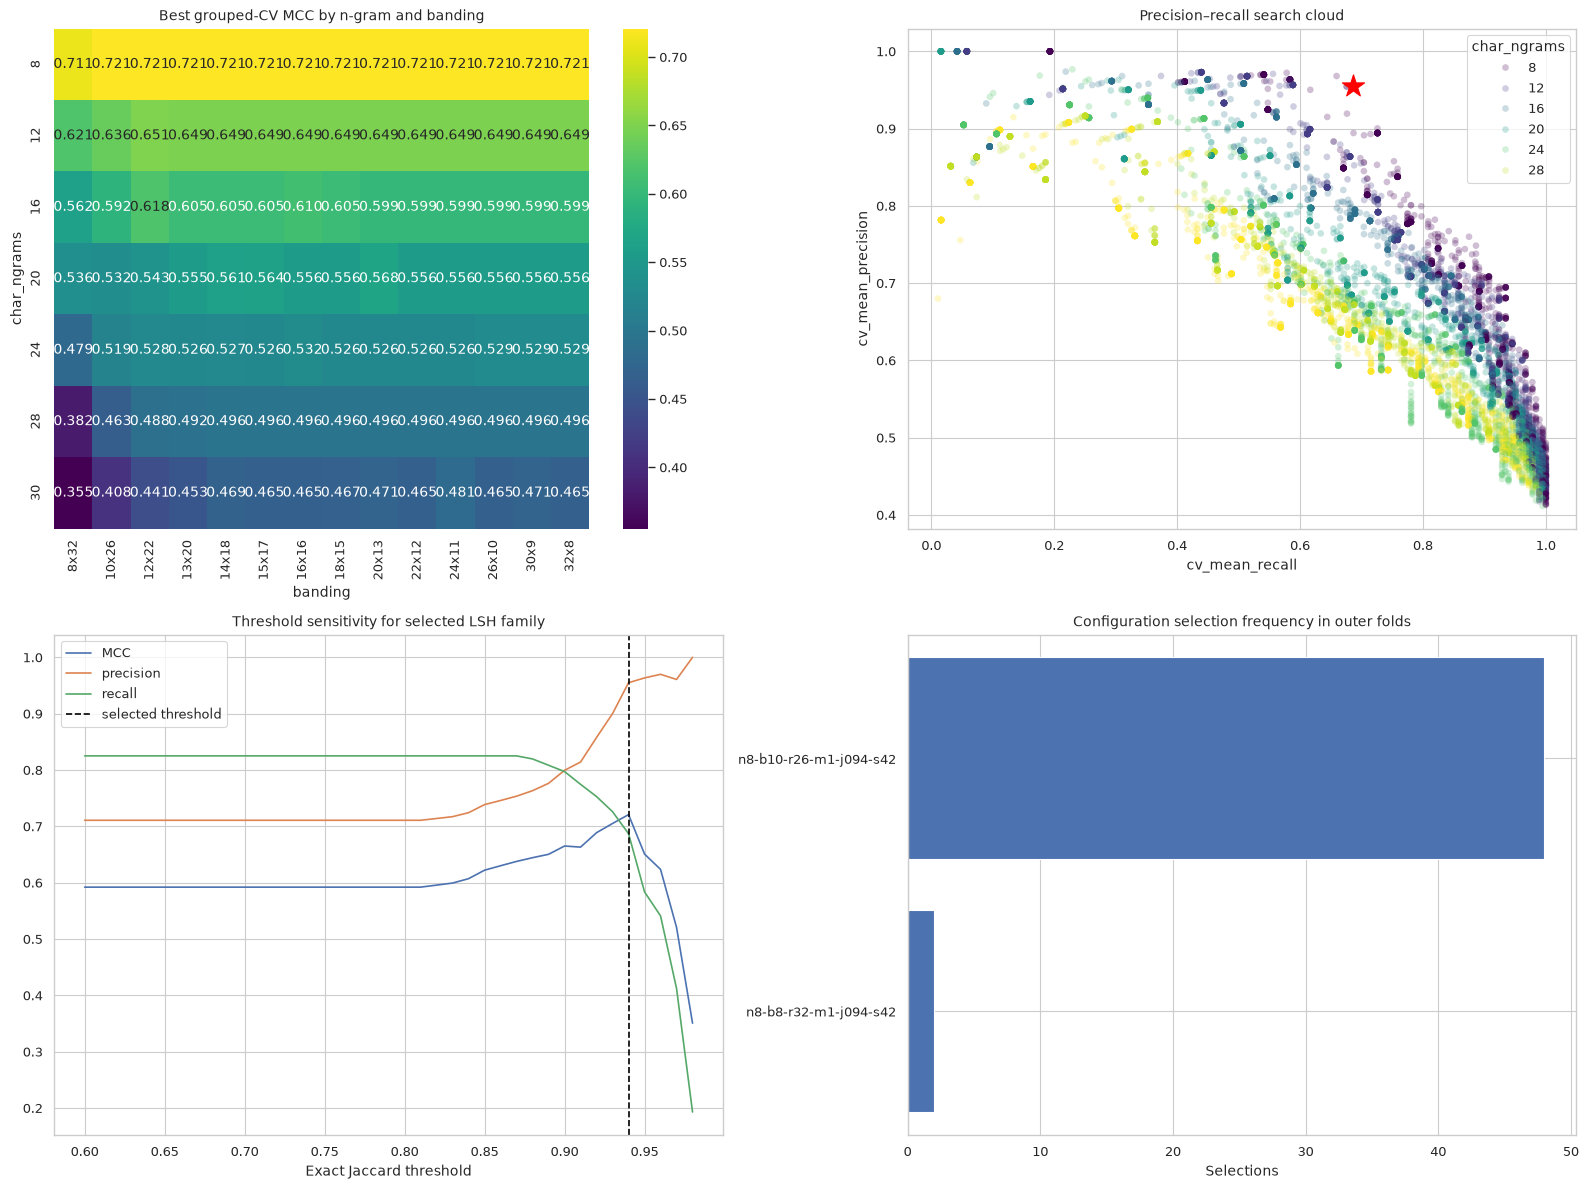

In [7]:
def wilson_interval(
    successes: int,
    total: int,
    z: float = 1.959963984540054,
) -> tuple[float, float]:
    if total == 0:
        return np.nan, np.nan
    proportion = successes / total
    denominator = 1 + z**2 / total
    center = (proportion + z**2 / (2 * total)) / denominator
    margin = (
        z
        * math.sqrt(
            proportion * (1 - proportion) / total
            + z**2 / (4 * total**2)
        )
        / denominator
    )
    return center - margin, center + margin


def metrics_from_confusion_array(counts: np.ndarray) -> pd.DataFrame:
    tp, fp, tn, fn = (counts[:, index] for index in range(4))
    precision = safe_ratio_array(tp, tp + fp)
    recall = safe_ratio_array(tp, tp + fn)
    specificity = safe_ratio_array(tn, tn + fp)
    f1 = safe_ratio_array(2 * tp, 2 * tp + fp + fn)
    denominator = np.sqrt(
        (tp + fp).astype(float)
        * (tp + fn)
        * (tn + fp)
        * (tn + fn)
    )
    mcc = np.zeros(len(counts), dtype=float)
    np.divide(tp * tn - fp * fn, denominator, out=mcc, where=denominator != 0)
    return pd.DataFrame({
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "balanced_accuracy": np.nanmean(np.vstack([recall, specificity]), axis=0),
        "mcc": mcc,
        "accuracy": safe_ratio_array(tp + tn, tp + fp + tn + fn),
    })


selected_configuration = None
selected_metrics = None
bootstrap_intervals = pd.DataFrame()
error_sample = pd.DataFrame()

if prediction_matrix is not None and selected_config_id is not None:
    selected_configuration = configurations.iloc[selected_config_id]
    selected_predictions = prediction_matrix[selected_config_id]
    selected_metrics = scalar_metrics(target, selected_predictions)
    selected_width = int(selected_configuration["char_ngrams"])
    selected_jaccard = jaccard_cache[selected_width]

    precision_interval = wilson_interval(
        int(selected_metrics["tp"]),
        int(selected_metrics["tp"] + selected_metrics["fp"]),
    )
    recall_interval = wilson_interval(
        int(selected_metrics["tp"]),
        int(selected_metrics["tp"] + selected_metrics["fn"]),
    )
    specificity_interval = wilson_interval(
        int(selected_metrics["tn"]),
        int(selected_metrics["tn"] + selected_metrics["fp"]),
    )

    unique_groups = np.sort(pairs["group_id"].unique())
    group_confusion = []
    for group_id in unique_groups:
        mask = groups == group_id
        group_metrics = scalar_metrics(target[mask], selected_predictions[mask])
        group_confusion.append([
            group_metrics["tp"], group_metrics["fp"],
            group_metrics["tn"], group_metrics["fn"],
        ])
    group_confusion = np.asarray(group_confusion, dtype=np.int64)

    bootstrap_rng = np.random.default_rng(CV_SEED)
    bootstrap_weights = bootstrap_rng.multinomial(
        len(unique_groups),
        np.full(len(unique_groups), 1 / len(unique_groups)),
        size=BOOTSTRAP_REPLICATES,
    )
    bootstrap_counts = bootstrap_weights @ group_confusion
    bootstrap_metrics = metrics_from_confusion_array(bootstrap_counts)
    bootstrap_intervals = pd.DataFrame({
        "metric": bootstrap_metrics.columns,
        "estimate": [selected_metrics[metric] for metric in bootstrap_metrics.columns],
        "bootstrap_95_lower": bootstrap_metrics.quantile(0.025).to_numpy(),
        "bootstrap_95_upper": bootstrap_metrics.quantile(0.975).to_numpy(),
    })

    selected_parameter_table = selected_configuration.to_frame(name="value")
    selected_performance_table = pd.Series({
        **selected_metrics,
        "precision_wilson_95_lower": precision_interval[0],
        "precision_wilson_95_upper": precision_interval[1],
        "recall_wilson_95_lower": recall_interval[0],
        "recall_wilson_95_upper": recall_interval[1],
        "specificity_wilson_95_lower": specificity_interval[0],
        "specificity_wilson_95_upper": specificity_interval[1],
    }, name="value").to_frame()

    display(Markdown("### Provisional selected parameters"))
    display(selected_parameter_table)
    display(Markdown("### Descriptive full-panel performance"))
    display(selected_performance_table)
    display(Markdown("### Component-bootstrap uncertainty"))
    display(bootstrap_intervals)
    display(Markdown("### Nested selection-procedure summary"))
    display(nested_repeat_metrics.describe().T)

    diagnostic_frame = pairs[[
        "pair_key", "label", "left_text", "right_text",
    ]].copy()
    diagnostic_frame["target_duplicate"] = target
    diagnostic_frame["predicted_duplicate"] = selected_predictions
    diagnostic_frame["exact_jaccard"] = selected_jaccard
    diagnostic_frame["error_type"] = np.select(
        [
            ~diagnostic_frame["target_duplicate"] & diagnostic_frame["predicted_duplicate"],
            diagnostic_frame["target_duplicate"] & ~diagnostic_frame["predicted_duplicate"],
        ],
        ["false_positive", "false_negative"],
        default="correct",
    )
    false_positives = (
        diagnostic_frame[diagnostic_frame["error_type"].eq("false_positive")]
        .sort_values(["exact_jaccard", "pair_key"], ascending=[False, True])
        .head(8)
    )
    false_negatives = (
        diagnostic_frame[diagnostic_frame["error_type"].eq("false_negative")]
        .sort_values(["exact_jaccard", "pair_key"], ascending=[False, True])
        .head(8)
    )
    error_sample = pd.concat([false_positives, false_negatives], ignore_index=True)
    error_sample["left_preview"] = error_sample["left_text"].str.slice(0, 240)
    error_sample["right_preview"] = error_sample["right_text"].str.slice(0, 240)
    display(Markdown("### Deterministic error sample"))
    display(error_sample[[
        "error_type", "label", "exact_jaccard", "pair_key",
        "left_preview", "right_preview",
    ]])

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    best_surface = (
        cv_ranking.assign(
            banding=cv_ranking["num_bands"].astype(str)
            + "x"
            + cv_ranking["minhashes_per_band"].astype(str)
        )
        .groupby(["char_ngrams", "banding"], as_index=False)["cv_mean_mcc"]
        .max()
        .pivot(index="char_ngrams", columns="banding", values="cv_mean_mcc")
    )
    best_surface = best_surface.reindex(
        columns=[f"{bands}x{rows}" for bands, rows in BANDINGS]
    )
    sns.heatmap(best_surface, cmap="viridis", annot=True, fmt=".3f", ax=axes[0, 0])
    axes[0, 0].set_title("Best grouped-CV MCC by n-gram and banding")

    sns.scatterplot(
        data=cv_ranking,
        x="cv_mean_recall",
        y="cv_mean_precision",
        hue="char_ngrams",
        palette="viridis",
        alpha=0.25,
        linewidth=0,
        ax=axes[0, 1],
    )
    axes[0, 1].scatter(
        [cv_ranking.loc[cv_ranking["selected"], "cv_mean_recall"].iloc[0]],
        [cv_ranking.loc[cv_ranking["selected"], "cv_mean_precision"].iloc[0]],
        marker="*",
        s=280,
        color="red",
        label="selected",
    )
    axes[0, 1].set_title("Precision–recall search cloud")

    selected_family = cv_ranking[
        cv_ranking["char_ngrams"].eq(selected_configuration["char_ngrams"])
        & cv_ranking["num_bands"].eq(selected_configuration["num_bands"])
        & cv_ranking["minhashes_per_band"].eq(selected_configuration["minhashes_per_band"])
        & cv_ranking["min_matching_bands"].eq(selected_configuration["min_matching_bands"])
        & cv_ranking["jaccard_threshold"].notna()
    ].sort_values("jaccard_threshold")
    axes[1, 0].plot(
        selected_family["jaccard_threshold"],
        selected_family["cv_mean_mcc"],
        label="MCC",
    )
    axes[1, 0].plot(
        selected_family["jaccard_threshold"],
        selected_family["cv_mean_precision"],
        label="precision",
    )
    axes[1, 0].plot(
        selected_family["jaccard_threshold"],
        selected_family["cv_mean_recall"],
        label="recall",
    )
    axes[1, 0].axvline(
        selected_configuration["jaccard_threshold"],
        color="black",
        linestyle="--",
        label="selected threshold",
    )
    axes[1, 0].set_title("Threshold sensitivity for selected LSH family")
    axes[1, 0].set_xlabel("Exact Jaccard threshold")
    axes[1, 0].legend()

    top_frequency = selection_frequency.head(12).sort_values("outer_fold_selections")
    axes[1, 1].barh(top_frequency["selected_slug"], top_frequency["outer_fold_selections"])
    axes[1, 1].set_title("Configuration selection frequency in outer folds")
    axes[1, 1].set_xlabel("Selections")

    plt.tight_layout()
    plt.show()


## 7. Reproducible artifacts

All artifacts are isolated by both the benchmark fingerprint and the search-specification hash. The source annotation remains read-only. Compact bit-packed predictions are used instead of a multi-million-row long table.


In [8]:
def json_native(value):
    if isinstance(value, dict):
        return {str(key): json_native(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_native(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, float) and np.isnan(value):
        return None
    return value


if RUN_SEARCH and prediction_matrix is not None and selected_configuration is not None:
    ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

    configurations.to_parquet(CONFIGURATIONS_PATH, index=False)
    pd.DataFrame({
        "pair_key": pairs["pair_key"],
        **{
            f"jaccard_n{width}": values
            for width, values in sorted(jaccard_cache.items())
        },
    }).to_parquet(JACCARD_PATH, index=False)
    fold_assignments.to_csv(FOLD_ASSIGNMENTS_PATH, index=False)
    full_configuration_metrics.to_parquet(CONFIGURATION_METRICS_PATH, index=False)
    cv_ranking.to_parquet(CV_RANKING_PATH, index=False)
    outer_fold_results.to_csv(OUTER_FOLD_RESULTS_PATH, index=False)
    outer_predictions.to_parquet(OUTER_PREDICTIONS_PATH, index=False)
    nested_repeat_metrics.to_csv(NESTED_REPEAT_METRICS_PATH, index=False)

    selected_payload = {
        "selection_objective": "mean grouped-cross-validation MCC",
        "parameters": selected_configuration.to_dict(),
        "descriptive_full_panel_metrics": selected_metrics,
        "component_bootstrap_intervals": bootstrap_intervals.to_dict(orient="records"),
        "nested_selection_repeat_metrics": nested_repeat_metrics.to_dict(orient="records"),
    }
    SELECTED_CONFIGURATION_PATH.write_text(
        json.dumps(json_native(selected_payload), ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    artifact_paths = [
        *[signature_path(width) for width in NGRAM_WIDTHS],
        PREDICTION_MATRIX_PATH,
        CONFIGURATIONS_PATH,
        JACCARD_PATH,
        FOLD_ASSIGNMENTS_PATH,
        CONFIGURATION_METRICS_PATH,
        CV_RANKING_PATH,
        OUTER_FOLD_RESULTS_PATH,
        OUTER_PREDICTIONS_PATH,
        NESTED_REPEAT_METRICS_PATH,
        SELECTED_CONFIGURATION_PATH,
    ]
    metadata = {
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "benchmark_fingerprint": benchmark_fingerprint,
        "search_specification_hash": search_spec_hash,
        "annotation_path": str(ANNOTATION_PATH),
        "annotation_sha256": annotation_sha256,
        "python_version": platform.python_version(),
        "nemo_curator_version": importlib.metadata.version("nemo-curator"),
        "cuda_visible_devices": os.environ["CUDA_VISIBLE_DEVICES"],
        "gpu_description": GPU_DESCRIPTION,
        "pairs": len(pairs),
        "unique_complete_items": len(all_item_ids),
        "leakage_groups": int(pairs["group_id"].nunique()),
        "configurations": len(configurations),
        "predictions": int(prediction_matrix.size),
        "search_specification": search_specification,
        "selected_slug": selected_configuration["slug"],
        "artifact_sha256": {
            str(path.relative_to(ARTIFACT_ROOT)): file_sha256(path)
            for path in artifact_paths
        },
    }
    METADATA_PATH.write_text(
        json.dumps(json_native(metadata), ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

required_artifacts = [
    *[signature_path(width) for width in NGRAM_WIDTHS],
    PREDICTION_MATRIX_PATH,
    CONFIGURATIONS_PATH,
    JACCARD_PATH,
    FOLD_ASSIGNMENTS_PATH,
    CONFIGURATION_METRICS_PATH,
    CV_RANKING_PATH,
    OUTER_FOLD_RESULTS_PATH,
    OUTER_PREDICTIONS_PATH,
    NESTED_REPEAT_METRICS_PATH,
    SELECTED_CONFIGURATION_PATH,
    METADATA_PATH,
]
missing_artifacts = [str(path) for path in required_artifacts if not path.is_file()]
if missing_artifacts:
    display(Markdown(f"Missing artifacts: {missing_artifacts}"))
elif prediction_matrix is not None:
    persisted_configurations = pd.read_parquet(CONFIGURATIONS_PATH)
    if len(persisted_configurations) != EXPECTED_CONFIGURATIONS:
        raise AssertionError("Persisted configuration count changed.")
    persisted_predictions = load_prediction_matrix(PREDICTION_MATRIX_PATH)
    if not np.array_equal(persisted_predictions, prediction_matrix):
        raise AssertionError("Persisted predictions changed.")
    for width in NGRAM_WIDTHS:
        persisted_signature = validate_signatures(
            np.load(signature_path(width), allow_pickle=False),
            signature_path(width),
        )
        if not np.array_equal(persisted_signature, signature_cache[width]):
            raise AssertionError(f"Persisted signature changed for n={width}.")
    persisted_selection = json.loads(SELECTED_CONFIGURATION_PATH.read_text(encoding="utf-8"))
    if persisted_selection["parameters"]["slug"] != selected_configuration["slug"]:
        raise AssertionError("Persisted selected configuration changed.")

    artifact_summary = pd.DataFrame([
        {
            "artifact": str(path.relative_to(ARTIFACT_ROOT)),
            "bytes": path.stat().st_size,
            "sha256": file_sha256(path),
        }
        for path in required_artifacts
    ])
    display(artifact_summary)


,artifact,bytes,sha256
0,signatures/minhash-n8-s42-h270.npy,1006688,150707e8eabd7227c8ac3acf336eac269063586fe0d2b987115dc935ac261d3d
1,signatures/minhash-n12-s42-h270.npy,1006688,d4873cbae2b08fca306c34d359013764b99eb7b0579b73b8f9ac5e111adc0aff
2,signatures/minhash-n16-s42-h270.npy,1006688,7ffd594221d7707f4df2bc7a842e9840d4da9145589d293140327d88fff6515c
3,signatures/minhash-n20-s42-h270.npy,1006688,76ba53fdbd62f5383be8c2d19d3b0372f6128416a1763b7e1a9fe9599565654a
4,signatures/minhash-n24-s42-h270.npy,1006688,d16af32117c1b682a76bf0d038b3ad72c3451e502e87d622ac12b37d50d35607
5,signatures/minhash-n28-s42-h270.npy,1006688,fbdfb7a7308a41375123b1f22e2900f4c73aed4b1412dc8a681de554405befab
6,signatures/minhash-n30-s42-h270.npy,1006688,90e6ea0406f4b361c119ed81e3d12f41a4ba050574e41cd0744b4252d6574786
7,predictions.npz,39793,23c5fc23b57546a6105ccdd231bed3d6fe6de4cfe7e86db238e8e1fa345ea08a
8,configurations.parquet,101254,854deeec133b83596e0980f78423f3a2a83b8ef0c53e4a3889dbe5a951d92baa
9,exact_jaccard.parquet,89461,72f267b0260dff818f6538905753529bd65c2daac9daa90c4b7d5f312768fe15


## 8. Interpretation boundaries

- The selected configuration is optimized for MCC, with precision and recall used only as deterministic tie-breakers.
- Seed 42 is fixed throughout; there is no seed optimization, voting, or consensus.
- The 466 pairs are an enriched fuzzy-candidate panel rather than a random sample of all corpus pairs.
- Nested grouped cross-validation reduces selection optimism and item leakage, but it cannot remove the original sampling bias or turn LLM labels into universal ground truth.
- The benchmark measures independent pair decisions. Connected-component chaining and representative selection are deliberately outside this notebook.
- The reported operating point is provisional and must be validated at component level before any automatic removal policy is considered.
